# IMPORT

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
from tqdm import tqdm
import cv2
import librosa.display



# DATASET

In [2]:
DATASET_PATH = "dataset/ravdess"

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

data = []

for actor in os.listdir(DATASET_PATH):
    actor_path = f"{DATASET_PATH}/{actor}"

    for file in os.listdir(actor_path):
        parts = file.split("-")

        emotion = emotion_map[parts[2]]

        data.append({
            "path": f"{actor_path}/{file}",
            "emotion": emotion,
            "actor": parts[6].split(".")[0]
        })

df = pd.DataFrame(data)

df.head()

,path,emotion,actor
0,dataset/ravdess/Actor_01/03-01-01-01-01-01-01.wav,neutral,01
1,dataset/ravdess/Actor_01/03-01-01-01-01-02-01.wav,neutral,01
2,dataset/ravdess/Actor_01/03-01-01-01-02-01-01.wav,neutral,01
3,dataset/ravdess/Actor_01/03-01-01-01-02-02-01.wav,neutral,01
4,dataset/ravdess/Actor_01/03-01-02-01-01-01-01.wav,calm,01


In [3]:
print(df.shape)
print(f"emotions: {len(df.emotion)}")
print(f"actors: {df.actor.nunique()}")


(1440, 3)
emotions: 1440
actors: 24


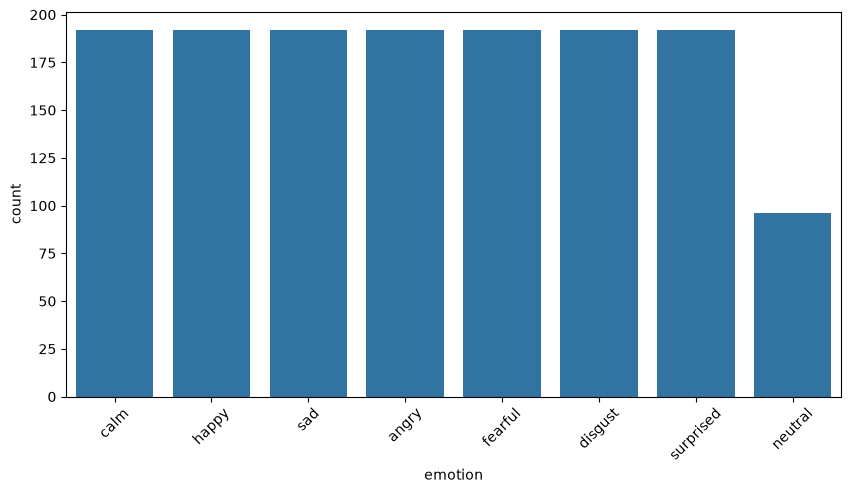

In [4]:
plt.figure(figsize=(10, 5))  #type: ignore

sns.countplot(
    data=df,
    x='emotion',
    order=df['emotion'].value_counts().index
)

plt.xticks(rotation=45)
plt.show()

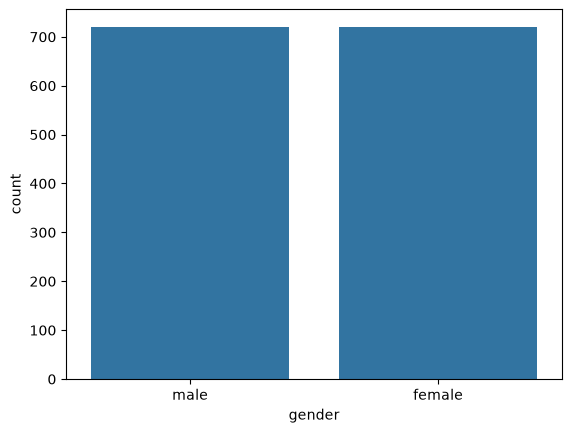

In [5]:
df['gender'] = df['actor'].astype(int).apply(
    lambda x: 'male' if x % 2 else 'female'
)

sns.countplot(data=df, x='gender')
plt.show()

In [6]:
pd.crosstab(df.gender, df.emotion)

emotion,angry,calm,disgust,fearful,happy,neutral,sad,surprised
gender,,,,,,,,
female,96,96,96,96,96,48,96,96
male,96,96,96,96,96,48,96,96


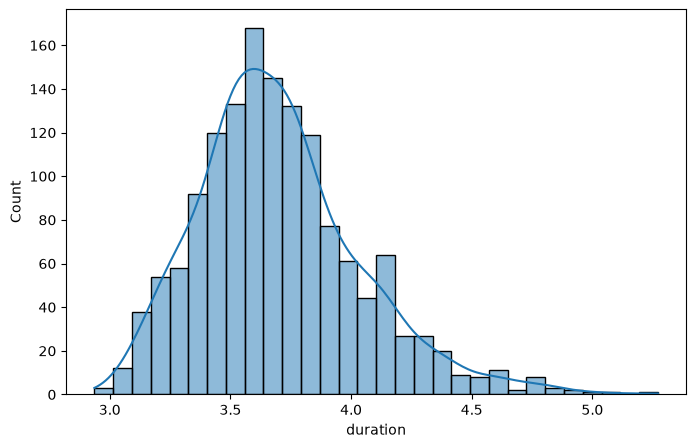

In [ ]:
durations = []

for path in df.path:
    y, sr = librosa.load(path, sr=None)

    durations.append(
        librosa.get_duration(y=y, sr=sr)
    )

df["duration"] = durations

plt.figure(figsize=(8, 5))  #type: ignore

sns.histplot(
    df.duration, # type: ignore
    bins=30,
    kde=True
)

plt.show()

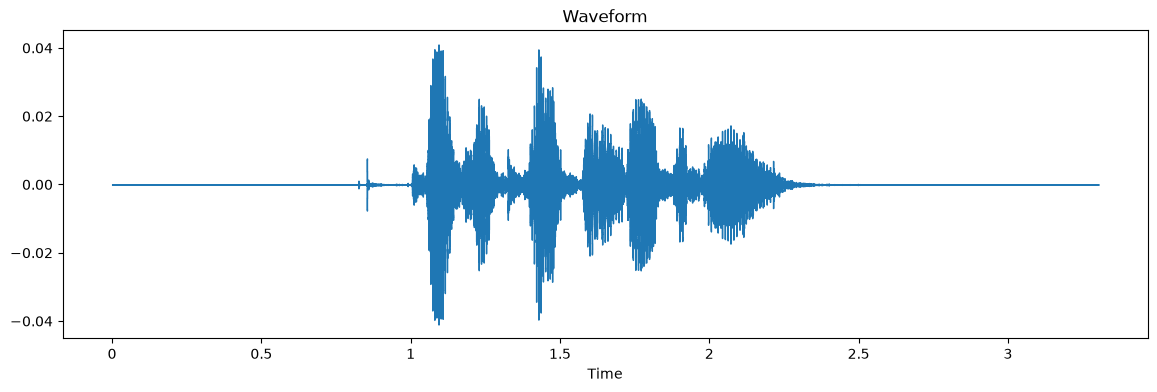

In [8]:
import librosa.display

sample = df.iloc[0].path

y, sr = librosa.load(sample)

plt.figure(figsize=(14, 4))  #type:ignore

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")
plt.show()

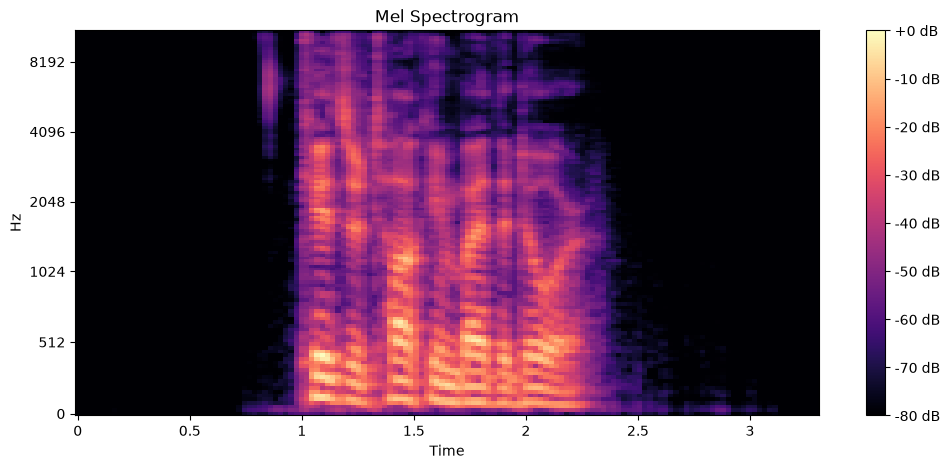

In [9]:
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()

In [10]:

TARGET_SR       = 22050
TARGET_DURATION = 3.0
TARGET_SAMPLES  = int(TARGET_SR * TARGET_DURATION)

N_MELS     = 128
N_FFT      = 1024
HOP_LENGTH = 512
WIN_LENGTH = 1024
IMG_SIZE   = (224, 224)


def extract_melspec(path, target_samples=TARGET_SAMPLES):
    """
    Output: (3, 224, 224) float32
      channel 0 — Mel Spectrogram (dB)
      channel 1 — Delta  : tốc độ thay đổi năng lượng theo thời gian
      channel 2 — Delta2 : gia tốc thay đổi (curvature)
    """
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)))
    else:
        y = y[:target_samples]

    mel    = librosa.feature.melspectrogram(
                y=y, sr=sr, n_mels=N_MELS,
                n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)   # (128, T)

    delta  = librosa.feature.delta(mel_db)           # tốc độ
    delta2 = librosa.feature.delta(mel_db, order=2)  # gia tốc

    def normalize_resize(arr):
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)  # [0, 1]
        return cv2.resize(arr, IMG_SIZE, interpolation=cv2.INTER_LINEAR)

    feat = np.stack([
        normalize_resize(mel_db),
        normalize_resize(delta),
        normalize_resize(delta2),
    ], axis=0)  # (3, 224, 224)

    return feat.astype(np.float32)


shape : (3, 224, 224)
dtype : float32
range : [0.000, 0.995]


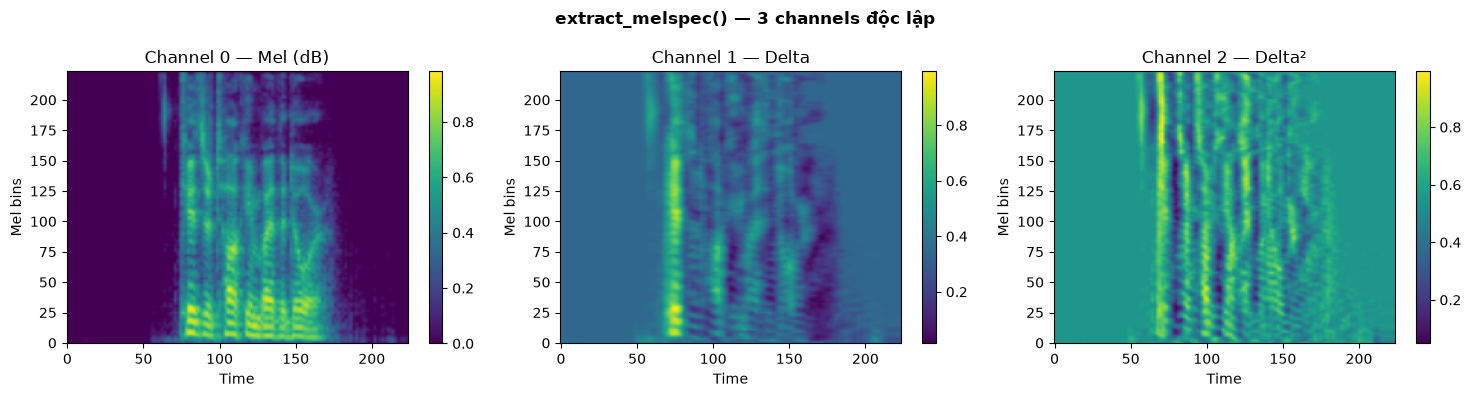

In [11]:
# ── Sanity check ───────────────────────────────────────────────
sample_path = df.iloc[0].path
feat = extract_melspec(sample_path)
print(f'shape : {feat.shape}')   # (3, 224, 224)
print(f'dtype : {feat.dtype}')   # float32
print(f'range : [{feat.min():.3f}, {feat.max():.3f}]')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Channel 0 — Mel (dB)', 'Channel 1 — Delta', 'Channel 2 — Delta²']
for i, ax in enumerate(axes):
    im = ax.imshow(feat[i], aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(titles[i])
    ax.set_xlabel('Time')
    ax.set_ylabel('Mel bins')
    fig.colorbar(im, ax=ax)
plt.suptitle('extract_melspec() — 3 channels độc lập', fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:

OUTPUT_DIR = 'features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

failed = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        feat = extract_melspec(row.path)  # (3, 224, 224)

        # Đặt tên file theo index để map lại với df
        save_path = os.path.join(OUTPUT_DIR, f'{idx}.npy')
        np.save(save_path, feat)

    except Exception as e:
        failed.append((idx, str(e)))

print(f'Saved   : {len(df) - len(failed)} files → {OUTPUT_DIR}/')
print(f'Failed  : {len(failed)}')
if failed:
    print(failed)

# Lưu df kèm cột feat_path để dùng trong DataLoader
df['feat_path'] = df.index.map(lambda i: os.path.join(OUTPUT_DIR, f'{i}.npy'))

os.makedirs("CSVs", exist_ok=True)
df.to_csv('CSVs/metadata.csv', index=False)
print('Metadata saved → CSVs/metadata.csv')


100%|██████████| 1440/1440 [00:12<00:00, 112.04it/s]

Saved   : 1440 files → features/
Failed  : 0
Metadata saved → CSVs/metadata.csv
